In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, resnet101, resnet152, ResNet50_Weights, ResNet101_Weights, ResNet152_Weights
from PIL import Image
from sklearn.model_selection import train_test_split

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seeds set!")

Seeds set!


In [2]:
TRAIN_DIR   = "./train"

LABEL_MAP = {
    "bedroom": 1, "Coast": 2, "Forest": 3, "Highway": 4,
    "industrial": 5, "Insidecity": 6, "kitchen": 7, "livingroom": 8,
    "Mountain": 9, "Office": 10, "OpenCountry": 11, "store": 12,
    "Street": 13, "Suburb": 14, "TallBuilding": 15,
}
NUM_CLASSES = 15
IMG_SIZE    = 224
BATCH_SIZE  = 32
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
def load_data(data_dir):
    paths, labels = [], []
    for class_name, label in LABEL_MAP.items():
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"[WARN] Missing: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(class_dir, fname))
                labels.append(label - 1)
    return paths, labels

train_val_paths, train_val_labels = load_data(TRAIN_DIR)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.2, stratify=train_val_labels, random_state=42
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

Train: 1200 | Val: 300


In [4]:
class SceneDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds = SceneDataset(train_paths, train_labels, transform=train_transform)
val_ds   = SceneDataset(val_paths,   val_labels,   transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Dataloaders ready!")

Dataloaders ready!


In [6]:
ARCH = "resnet152"
LR   = 1e-4

set_seed(42)

model = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)

# Plain linear head
model.fc = nn.Linear(2048, NUM_CLASSES)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

model = model.to(DEVICE)
print(f"{ARCH.upper()} | LR={LR} | Unfreeze all | hflip + brightness")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

RESNET152 | LR=0.0001 | Unfreeze all | hflip + brightness
Trainable params: 58,174,543


In [7]:
set_seed(42)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

best_val_acc        = 0.0
patience_counter    = 0
EARLY_STOP_PATIENCE = 7

train_acc_history = []
val_acc_history   = []

for epoch in range(50):
    model.train()
    train_correct, train_total = 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss    += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    train_acc    = train_correct / train_total
    val_acc      = val_correct   / val_total
    val_loss_avg = val_loss / len(val_loader)

    train_acc_history.append(train_acc * 100)
    val_acc_history.append(val_acc * 100)

    scheduler.step(val_loss_avg)

    print(f"Epoch {epoch+1:02d} | Train: {train_acc*100:.2f}% | Val: {val_acc*100:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "trained_cnn_res.pth")
        print(f"  ✓ Saved best model: {best_val_acc*100:.2f}%")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")

Epoch 01 | Train: 56.83% | Val: 84.33% | LR: 0.000100
  ✓ Saved best model: 84.33%
Epoch 02 | Train: 91.67% | Val: 91.00% | LR: 0.000100
  ✓ Saved best model: 91.00%
Epoch 03 | Train: 96.33% | Val: 90.00% | LR: 0.000100
Epoch 04 | Train: 97.67% | Val: 94.00% | LR: 0.000100
  ✓ Saved best model: 94.00%
Epoch 05 | Train: 98.50% | Val: 91.67% | LR: 0.000100
Epoch 06 | Train: 99.50% | Val: 92.00% | LR: 0.000100
Epoch 07 | Train: 98.92% | Val: 92.33% | LR: 0.000100
Epoch 08 | Train: 98.50% | Val: 91.67% | LR: 0.000050
Epoch 09 | Train: 99.58% | Val: 93.33% | LR: 0.000050
Epoch 10 | Train: 99.83% | Val: 94.67% | LR: 0.000050
  ✓ Saved best model: 94.67%
Epoch 11 | Train: 99.75% | Val: 94.67% | LR: 0.000050
Epoch 12 | Train: 99.83% | Val: 94.00% | LR: 0.000050
Epoch 13 | Train: 99.92% | Val: 94.67% | LR: 0.000050
Epoch 14 | Train: 99.75% | Val: 95.33% | LR: 0.000050
  ✓ Saved best model: 95.33%
Epoch 15 | Train: 99.92% | Val: 94.33% | LR: 0.000050
Epoch 16 | Train: 99.92% | Val: 94.33% | LR: 

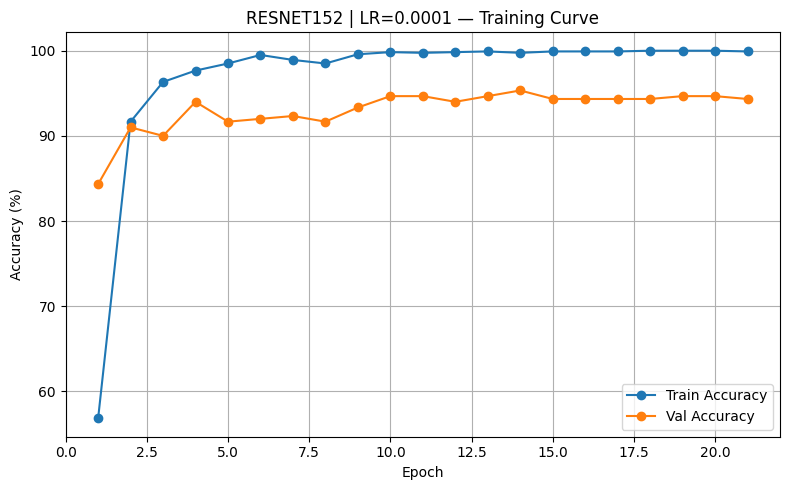

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc_history, label="Train Accuracy", marker="o")
plt.plot(epochs, val_acc_history,   label="Val Accuracy",   marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title(f"{ARCH.upper()} | LR={LR} — Training Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

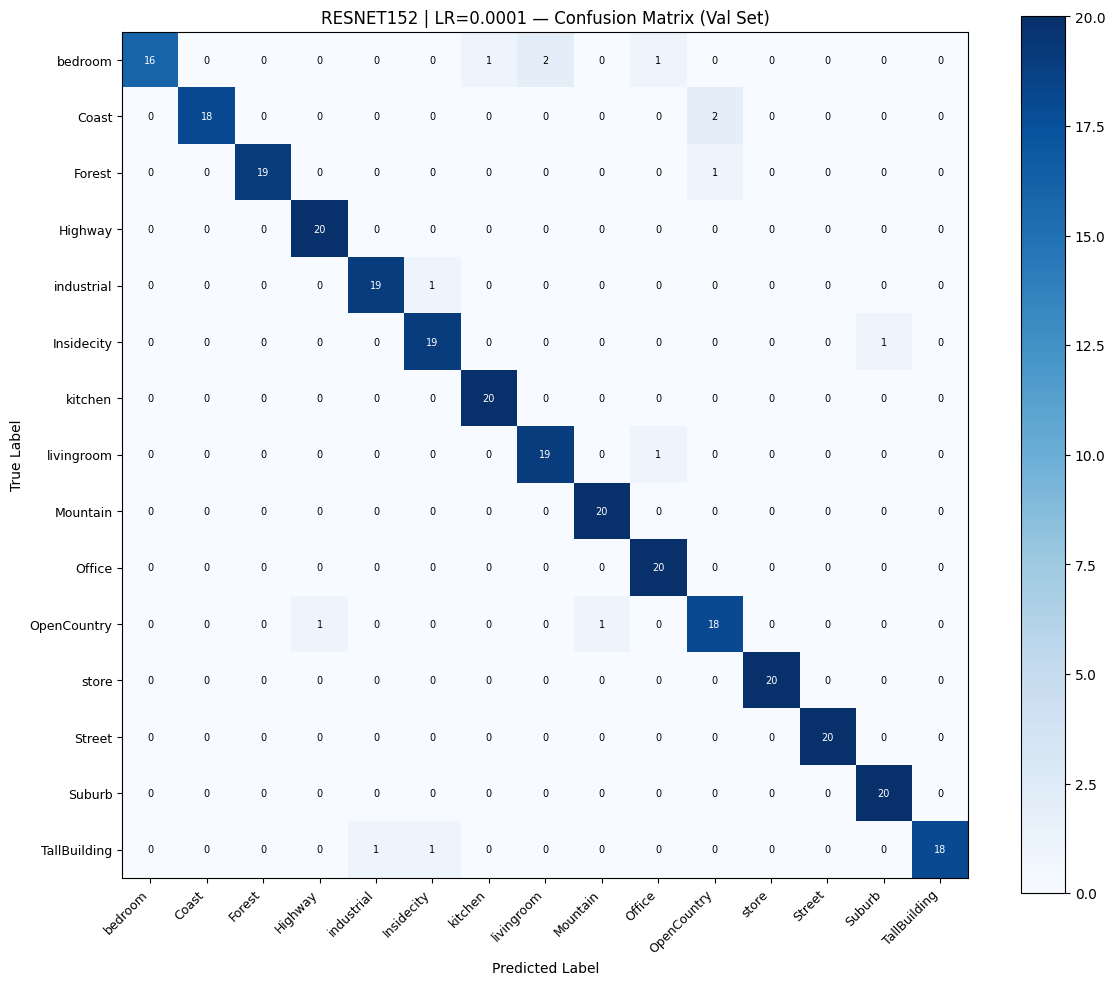

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

class_names = [
    "bedroom", "Coast", "Forest", "Highway", "industrial",
    "Insidecity", "kitchen", "livingroom", "Mountain", "Office",
    "OpenCountry", "store", "Street", "Suburb", "TallBuilding"
]

model_val = resnet152(weights=None)
model_val.fc = nn.Linear(2048, NUM_CLASSES)
model_val.load_state_dict(torch.load("trained_cnn_res.pth"))
model_val = model_val.to(DEVICE)
model_val.eval()

val_preds, val_true = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model_val(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        val_preds.extend(preds)
        val_true.extend(labels.numpy())

cm = confusion_matrix(val_true, val_preds)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(class_names, fontsize=9)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"{ARCH.upper()} | LR={LR} — Confusion Matrix (Val Set)")
plt.tight_layout()

plt.show()

In [10]:
from sklearn.metrics import classification_report

report = classification_report(
    val_true, val_preds,
    target_names=class_names,
    digits=4
)
print(f"{ARCH.upper()} | LR={LR} — Classification Report (Val Set)")
print(report)

RESNET152 | LR=0.0001 — Classification Report (Val Set)
              precision    recall  f1-score   support

     bedroom     1.0000    0.8000    0.8889        20
       Coast     1.0000    0.9000    0.9474        20
      Forest     1.0000    0.9500    0.9744        20
     Highway     0.9524    1.0000    0.9756        20
  industrial     0.9500    0.9500    0.9500        20
  Insidecity     0.9048    0.9500    0.9268        20
     kitchen     0.9524    1.0000    0.9756        20
  livingroom     0.9048    0.9500    0.9268        20
    Mountain     0.9524    1.0000    0.9756        20
      Office     0.9091    1.0000    0.9524        20
 OpenCountry     0.8571    0.9000    0.8780        20
       store     1.0000    1.0000    1.0000        20
      Street     1.0000    1.0000    1.0000        20
      Suburb     0.9524    1.0000    0.9756        20
TallBuilding     1.0000    0.9000    0.9474        20

    accuracy                         0.9533       300
   macro avg     0.9557 